<a href="https://colab.research.google.com/github/f1514454-sys/AML-Final-Minaya-Andrea/blob/main/notebooks/AML-Final-Minaya-Andrea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Capstone Project - Advanced Machine Learning
## TEC-VIII Programa de Especialización en Big Data Analytics aplicada a los Negocios

---

### 📋 Información del Proyecto

| Campo | Información |
|-------|-------------|
| **Nombre del Estudiante** | [Andrea Alejandra Minaya Limaylla] |
| **Título del Proyecto** | [Optimización de Gestión de Cobranza de  cartera castigada en Campo] |
| **Fecha de Entrega** | [21/03/2026] |
| **Profesor** | [Carlos M.] |

---

## 📑 Índice

1. [Resumen Ejecutivo](#1-resumen-ejecutivo)
2. [Configuración del Entorno](#2-configuración-del-entorno)
3. [Definición del Problema de Negocio](#3-definición-del-problema-de-negocio)
4. [Carga y Exploración de Datos](#4-carga-y-exploración-de-datos)
5. [Preprocesamiento de Datos](#5-preprocesamiento-de-datos)
6. [Diseño y Arquitectura del Modelo](#6-diseño-y-arquitectura-del-modelo)
7. [Entrenamiento del Modelo](#7-entrenamiento-del-modelo)
8. [Evaluación y Métricas](#8-evaluación-y-métricas)
9. [Interpretación de Resultados](#9-interpretación-de-resultados)
10. [Conclusiones y Recomendaciones de Negocio](#10-conclusiones-y-recomendaciones-de-negocio)
11. [Referencias](#11-referencias)

---
## 1. Resumen Ejecutivo

**Instrucciones:** Proporcione un resumen conciso (máximo 300 palabras) que incluya:
- Problema de negocio abordado
- Metodología utilizada
- Principales hallazgos
- Impacto esperado en el negocio

---

* Problema de Negocio:

Actualmente, la gestión de visitas de cobranza presenta una deficiencia operativa crítica debido a la fragmentación de la información. A pesar de contar con criterios básicos de priorización, los ejecutivos de campo carecen de una visión integral del cliente, ya que los datos históricos y de diversos sistemas no están integrados. Esto genera una toma de decisiones subjetiva por parte del personal, donde las rutas y visitas ejecutadas no son necesariamente las más óptimas para la recuperación. Asimismo, existe un riesgo regulatorio latente de incurrir en prácticas de cobranza abusivas por falta de un modelo de gestión estandarizado y basado en datos.

* Metodología:

Para revertir esta situación, se propone la implementación de un Modelo de Gestión Integrado que consolide la información alojada en distintos silos sistémicos. Este enfoque se centrará en:

•	Integración de datos: Habilitar información histórica y de comportamiento crediticio en una sola plataforma.

•	Optimización de rutas: Sustituir la decisión discrecional del ejecutivo por un modelo de asignación basado en probabilidad de éxito y eficiencia logística.

•	Gobierno de cumplimiento: Establecer parámetros que aseguren que la gestión se mantenga dentro de los marcos regulatorios para evitar sanciones.

* Principales Hallazgos

•	Subutilización de datos: Existe un volumen valioso de información recogida en periodos anteriores que actualmente se ignora.

•	Brecha de efectividad: La operatividad actual solo alcanza una efectividad de recuperación del 0.23%, evidenciando que el modelo basado en la decisión humana sin soporte analítico ha llegado a su techo.

* Impacto Esperado

El proyecto proyecta una transformación financiera significativa al elevar la meta de efectividad del 0.23% al 0.7%. Esto se traduce en:

•	Recuperación incremental: Un impacto directo de 1.4 millones de soles adicionales en cartera castigada (provisionada al 100%).

•	Eficiencia financiera: Captura de montos adicionales mediante la reducción de nuevas provisiones por mejora en el comportamiento de pago.





---

## 2. Configuración del Entorno

### 2.1 Verificación de GPU (Recomendado para Deep Learning)

In [42]:
# Verificar si hay GPU disponible
import torch

# Verificar disponibilidad de GPU
if torch.cuda.is_available():
    print(f"✅ GPU disponible: {torch.cuda.get_device_name(0)}")
    print(f"   Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    device = torch.device('cuda')
else:
    print("⚠️ GPU no disponible. Usando CPU.")
    print("   Recomendación: En Colab, vaya a Runtime > Change runtime type > GPU")
    device = torch.device('cpu')

print(f"\nDispositivo seleccionado: {device}")

⚠️ GPU no disponible. Usando CPU.
   Recomendación: En Colab, vaya a Runtime > Change runtime type > GPU

Dispositivo seleccionado: cpu


### 2.2 Instalación de Librerías Adicionales (si es necesario)

In [43]:
# Descomente e instale las librerías adicionales que necesite
!pip install transformers
!pip install pytorch-lightning
!pip install optuna
!pip install shap
!pip install lime

### 2.3 Importación de Librerías

In [44]:
# =====================================================
# LIBRERÍAS FUNDAMENTALES
# =====================================================

# Manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning - PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset

# Deep Learning - TensorFlow/Keras (alternativa)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             mean_squared_error, mean_absolute_error, r2_score)

# Utilidades
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

# Semilla para reproducibilidad
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("✅ Todas las librerías importadas correctamente")
print(f"   PyTorch version: {torch.__version__}")
print(f"   TensorFlow version: {tf.__version__}")

✅ Todas las librerías importadas correctamente
   PyTorch version: 2.10.0+cpu
   TensorFlow version: 2.19.0


### 2.4 Conexión con Google Drive (para cargar datos)

In [45]:
# Montar Google Drive para acceder a los datos
from google.colab import drive
drive.mount('/content/drive')

# Definir la ruta base de su proyecto
# Modifique esta ruta según la ubicación de sus datos
BASE_PATH = '/content/drive/MyDrive/AML-Final-Minaya-Andrea/'

print(f"✅ Google Drive montado")
print(f"   Ruta base del proyecto: {BASE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive montado
   Ruta base del proyecto: /content/drive/MyDrive/AML-Final-Minaya-Andrea/


---
## 3. Definición del Problema de Negocio

### 3.1 Contexto del Negocio

**Instrucciones:** Describa el contexto empresarial, incluyendo:
- Industria/Sector
- Empresa o caso de estudio
- Situación actual

---

El proyecto se enmarca en el Sector Bancario y Financiero, específicamente en el área de Gestión de Cobranzas y Recuperaciones de un banco importante de las microfinanzas en Perú. Este sector se caracteriza por un entorno altamente regulado, donde la eficiencia operativa debe equilibrarse estrictamente con el cumplimiento de normativas de protección al consumidor para evitar sanciones por cobranza abusiva.

La situación actual se caracteriza por una gestión operativa ineficiente del equipo de cobranzas en campo, derivada principalmente de la fragmentación de datos en múltiples sistemas que no se integran entre sí. Esta falta de visibilidad impide que la información histórica y el comportamiento crediticio real de los clientes se reflejen en el modelo de gestión, obligando a los ejecutivos a tomar decisiones subjetivas y discrecionales sobre sus rutas y prioridades, las cuales no garantizan resultados óptimos. Como consecuencia, la efectividad de recuperación de la cartera castigada se encuentra estancada en un 0.23%, mientras persiste un riesgo regulatorio latente debido a la falta de procesos estandarizados que aseguren una gestión de cobranza ética y eviten sanciones por malas praxis.

---

### 3.2 Problema a Resolver

**Instrucciones:** Defina claramente:
- ¿Cuál es el problema específico?
- ¿Por qué es importante resolverlo?
- ¿Cuál es el impacto actual del problema?

---

El problema específico es una deficiencia operativa en la cobranza de campo causada por la fragmentación de datos y la dependencia de criterios subjetivos, lo que impide priorizar visitas según el comportamiento histórico del cliente. Es imperativo resolverlo para estandarizar los procesos bajo normativas regulatorias que eviten gestiones abusivas. Actualmente, el impacto de esta situación se refleja en una efectividad de recuperación de apenas 0.23% y en un incremento sostenido de las provisiones, afectando el ROE del banco.

---

### 3.3 Objetivos del Proyecto

**Instrucciones:** Liste los objetivos SMART (Específicos, Medibles, Alcanzables, Relevantes, Temporales)

---

**Objetivo General:**

Implementar un modelo de priorización analítica que incremente la efectividad de recuperación en campo del 0.23% al 0.7% en un plazo de 6 meses, optimizando la asignación de rutas mediante el uso de datos históricos integrados.

**Objetivos Específicos:**

1.	Consolidar el 95% de la información de comportamiento crediticio y visitas históricas en una base de datos unificada durante los primeros 3 sprints.

2.	Desarrollar un modelo predictivo de propensión de pago que logre una métrica de desempeño (AUC) superior al 75% en el 6to sprint.

3.	Reducir en un 20% el tiempo de desplazamiento diario de los ejecutivos de campo durante el primer trimestre de implementación, mediante una asignación de cartera agrupada por distrito, asegurando que el 90% de las visitas de un gestor se concentren en una misma zona geográfica por día.

---

### 3.4 Tipo de Problema de Machine Learning

**Instrucciones:** Identifique el tipo de problema:
- [x] Clasificación binaria
- [ ] Clasificación multiclase
- [ ] Regresión
- [ ] Clustering
- [ ] Series temporales
- [ ] Procesamiento de Lenguaje Natural (NLP)
- [ ] Visión por Computadora
- [ ] Otro: _________

**Justificación:**

Se selecciona Clasificación Binaria dado que el modelo predice la probabilidad de que un cliente pague o no. Este resultado permite generar un ranking de prioridad que. Además, se complementará con una lógica de asignación por distritos incrementando la eficiencia de las visitas.


---

---
## 4. Carga y Exploración de Datos

### 4.1 Carga de Datos / Generación de datos sintética

In [46]:
# =====================================================
# CARGA DE DATOS
# =====================================================

# Opción 1: Cargar desde Google Drive
# df = pd.read_csv(BASE_PATH + 'datos.csv')

# Opción 2: Cargar desde URL
# df = pd.read_csv('https://url-de-sus-datos.com/datos.csv')

# Opción 3: Cargar desde archivo local (subido a Colab)
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv('nombre_archivo.csv')

# Opción 4: Dataset de ejemplo (para testing)
# from sklearn.datasets import load_iris, load_boston, fetch_california_housing
# data = load_iris()
# df = pd.DataFrame(data.data, columns=data.feature_names)
# df['target'] = data.target

# =====================================================
# COMPLETE AQUÍ: Cargue su dataset
# =====================================================

# df = pd.read_csv('...')  # Descomente y complete

#print(f"✅ Dataset cargado exitosamente")
#print(f"   Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")

# 1. Instalación
!pip install faker -q

import os
import pandas as pd
import numpy as np
from faker import Faker
import random
from google.colab import drive

# 2. Configuración (Cambiamos el locale para evitar el AttributeError)
fake = Faker('es_ES')
ruta_proyecto = '/content/drive/MyDrive/AML-Final-Minaya-Andrea/'

# 3. Montar Drive de forma segura
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 4. Función generadora (Mantenemos tus 60k registros)
def generar_poblacion_cobranza(n=60000):
    data = []
    # Definimos los distritos manualmente para asegurar que sean de Lima
    distritos_lima = ["MIRAFLORES", "SAN ISIDRO", "LOS OLIVOS", "ATE", "SURCO", "LA VICTORIA", "CALLAO", "SJL", "COMAS"]
    puestos = ["EJECUTIVO DE RECUPERACIONES", "SUPERVISOR", "GERENTE TERRITORIAL"]

    for _ in range(n):
        rcc_score = random.randint(0, 4)
        dias_mora = random.uniform(0, 8) if rcc_score == 0 else random.uniform(8 * rcc_score, 200)

        saldo_cuota = round(random.uniform(100, 5000), 2)
        saldo_inst = round(saldo_cuota * random.uniform(1, 8), 2)
        saldo_total_rcc = round(saldo_inst + random.uniform(0, 25000), 2)

        nom_colab = fake.name().upper()

        fila = {
            "PER_PRO": 202603,
            "COD_COLABORADOR": random.randint(100000, 999999),
            "NOM_COLABORADOR": nom_colab,
            "S_CORREO": f"{nom_colab.split()[0].lower()}@dominio.com.pe",
            "S_PUESTO": random.choice(puestos),
            "CO_CLIENTE": random.randint(10000000, 99999999),
            "NOMBRE_CLIENTE": fake.name().upper(),
            "DOI_CLIENTE": str(random.randint(10000000, 99999999)),
            "SALDO_CAPITAL_CUOTA": saldo_cuota,
            "SALDO_CAPITAL_TOTAL": saldo_inst,
            "SALDO_TOTAL": saldo_total_rcc,
            "RCC": rcc_score,
            "TRAMO_INI_OPE": round(dias_mora, 1),
            "DISTRITO_DOM_NEG": random.choice(distritos_lima), # Usamos nuestra lista de Lima
            "TARGET_PAGO": np.random.choice([0, 1], p=[0.77, 0.23])
        }
        data.append(fila)
    return pd.DataFrame(data)

# 5. Ejecución y Guardado
df = generar_poblacion_cobranza(60000)

if not os.path.exists(ruta_proyecto):
    os.makedirs(ruta_proyecto)

df.to_csv(os.path.join(ruta_proyecto, 'poblacion_60k_cobranza.csv'), index=False)

# 6. Confirmación Profesional
print(f"✅ Dataset cargado exitosamente")
print(f"   Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")

✅ Dataset cargado exitosamente
   Dimensiones: 60,000 filas × 15 columnas


### 4.2 Descripción del Dataset

**Instrucciones:** Describa su dataset:
- Fuente de los datos: Información del banco y Reporte de Crédito Consolidado
- Período de tiempo que cubren: 6 meses considerando desfase de 60 días de RCC
- Descripción de cada variable

---

| Campo | Tipo de Dato | Lógica / Formato de Ejemplo |
|---|---|---|
| PER_PRO | Numérico (Periodo) | Formato YYYYMM (ej. 202505). |
| COD_COLABORADOR | ID Numérico | Entero de 5 a 6 dígitos. |
| NOM_COLABORADOR | Texto | Nombres y apellidos completos en mayúsculas. |
| S_CORREO | Email | Formato institucional: nombre.apellido@dominio.com.pe. |
| S_PUESTO | Categoría | Cargos como "EJECUTIVO DE RECUPERACIONES", "SUPERVISOR". |
| COD_AGENCIA | ID Numérico | Código de sucursal (ej. 220). |
| NOM_AGENCIA | Texto | Nombre de la sede (ej. AG ALBARRACIN MUNICIPAL). |
| COD_SDR / COD_GT | ID Numérico | IDs de supervisores o gerentes (suelen coincidir con la jerarquía). |
| CO_CLIENTE | ID Numérico | Código único de cliente (ej. 10888581). |
| NOMBRE_CLIENTE | Texto | Apellidos y nombres del cliente en mayúsculas. |
| DOI_CLIENTE | Documento | DNI o RUC (8 o 11 dígitos). |
| NU_PRESTAMO | ID Numérico | Número de cuenta o contrato (aprox. 9 dígitos). |
| SALDO_CAPITAL_CUOTA | Decimal | Monto pendiente (ej. 8817.1). |
| SALDO_CAPITAL_TOTAL | Decimal | Monto pendiente de todos los préstamos en la institución (ej. 8817.1). |
| SALDO_TOTAL | Decimal | Monto pendiente de todos los préstamos de todos los bancos (ej. 8817.1). |
| RCC | Categoría | Clasificación RCC del 0 al 4 |
| TRAMO_INI_OPE | Decimal | Días en mora |
| CANT_MESES_CAST | Entero | Meses de castigo (ej. 8). |
| DIR_DOM / NEG / AVAL | Texto | Direcciones físicas completas (Urb, Jirón, Calle). |
| DISTRITO_DOM / NEG | Categoría | Nombres de distritos locales. |
| COORD_X / COORD_Y | Geográfico | Coordenadas con 6 decimales (ej. -71.575142, -16.428013). |
| TARGET_PAGO | Variable | Efectividad de pago |
---

### 4.3 Exploración Inicial de Datos (EDA)

In [47]:
# =====================================================
# INFORMACIÓN GENERAL DEL DATASET
# =====================================================

print("=" * 60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 60)

# Primeras filas
print("\n📊 Primeras 5 filas:")
display(df.head())

# Información del dataset
print("\n📋 Información del Dataset:")
print(df.info())

# Estadísticas descriptivas
print("\n📈 Estadísticas Descriptivas:")
display(df.describe())

INFORMACIÓN GENERAL DEL DATASET

📊 Primeras 5 filas:


,PER_PRO,COD_COLABORADOR,NOM_COLABORADOR,S_CORREO,S_PUESTO,CO_CLIENTE,NOMBRE_CLIENTE,DOI_CLIENTE,SALDO_CAPITAL_CUOTA,SALDO_CAPITAL_TOTAL,SALDO_TOTAL,RCC,TRAMO_INI_OPE,DISTRITO_DOM_NEG,TARGET_PAGO
0,202603,985294,CARLOTA OLIVÉ LOSA,carlota@dominio.com.pe,EJECUTIVO DE RECUPERACIONES,17965412,NANDO PALOMINO CAMACHO,12107178,4455.84,29999.42,52451.74,0,4.6,SURCO,0
1,202603,572932,OLIMPIA CORTÉS VIÑA,olimpia@dominio.com.pe,EJECUTIVO DE RECUPERACIONES,50644306,MARCELO CLEMENTE DÁVILA PEÑA,25454574,3887.44,8528.72,25378.55,3,75.5,LOS OLIVOS,1
2,202603,468179,SARITA RIVERA MORERA,sarita@dominio.com.pe,EJECUTIVO DE RECUPERACIONES,60865594,DUILIO DALMAU PUERTA,49249170,3268.26,15187.84,32786.95,3,111.8,LA VICTORIA,0
3,202603,882481,ROGELIO SATURNINO DALMAU CARPIO,rogelio@dominio.com.pe,SUPERVISOR,22239506,AMÉRICA VERDUGO POL,28864726,1261.47,9880.03,26191.92,0,7.7,SURCO,0
4,202603,547419,DÉBORA ESTER PADILLA ALEGRE,débora@dominio.com.pe,GERENTE TERRITORIAL,71829605,GALA DEL MATA,78091828,3400.91,4321.65,15669.31,2,130.3,SAN ISIDRO,0



📋 Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PER_PRO              60000 non-null  int64  
 1   COD_COLABORADOR      60000 non-null  int64  
 2   NOM_COLABORADOR      60000 non-null  object 
 3   S_CORREO             60000 non-null  object 
 4   S_PUESTO             60000 non-null  object 
 5   CO_CLIENTE           60000 non-null  int64  
 6   NOMBRE_CLIENTE       60000 non-null  object 
 7   DOI_CLIENTE          60000 non-null  object 
 8   SALDO_CAPITAL_CUOTA  60000 non-null  float64
 9   SALDO_CAPITAL_TOTAL  60000 non-null  float64
 10  SALDO_TOTAL          60000 non-null  float64
 11  RCC                  60000 non-null  int64  
 12  TRAMO_INI_OPE        60000 non-null  float64
 13  DISTRITO_DOM_NEG     60000 non-null  object 
 14  TARGET_PAGO          60000 non-null  int64  
dtypes: float

,PER_PRO,COD_COLABORADOR,CO_CLIENTE,SALDO_CAPITAL_CUOTA,SALDO_CAPITAL_TOTAL,SALDO_TOTAL,RCC,TRAMO_INI_OPE,TARGET_PAGO
count,60000.0,60000.000000,6.000000e+04,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,202603.0,550032.712167,5.506859e+07,2553.209243,11519.363689,24022.572099,2.005900,89.236892,0.228850
std,0.0,260061.468257,2.605330e+07,1417.582149,8678.965227,11273.428287,1.412007,63.118240,0.420096
min,202603.0,100001.000000,1.000179e+07,100.050000,126.130000,277.360000,0.000000,0.000000,0.000000
25%,202603.0,324670.250000,3.252191e+07,1327.597500,4483.305000,15681.865000,1.000000,32.200000,0.000000
50%,202603.0,550325.500000,5.513259e+07,2555.855000,9357.415000,23406.305000,2.000000,88.500000,0.000000
75%,202603.0,775744.250000,7.765019e+07,3784.360000,16959.962500,31153.267500,3.000000,144.700000,0.000000
max,202603.0,999982.000000,9.999899e+07,4999.820000,39822.680000,63726.620000,4.000000,200.000000,1.000000


In [48]:
# =====================================================
# ANÁLISIS DE VALORES FALTANTES
# =====================================================

print("=" * 60)
print("ANÁLISIS DE VALORES FALTANTES")
print("=" * 60)

# Calcular valores faltantes
missing_data = pd.DataFrame({
    'Total Faltantes': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Total Faltantes'] > 0].sort_values('Porcentaje (%)', ascending=False)

if len(missing_data) > 0:
    print("\n⚠️ Variables con valores faltantes:")
    display(missing_data)

    # Visualización de valores faltantes
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_data.index, y='Porcentaje (%)', data=missing_data)
    plt.title('Porcentaje de Valores Faltantes por Variable')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Porcentaje (%)')
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ No hay valores faltantes en el dataset")

ANÁLISIS DE VALORES FALTANTES

✅ No hay valores faltantes en el dataset


ANÁLISIS DE LA VARIABLE OBJETIVO: TARGET_PAGO

📊 Distribución de clases:
TARGET_PAGO
0    46269
1    13731
Name: count, dtype: int64


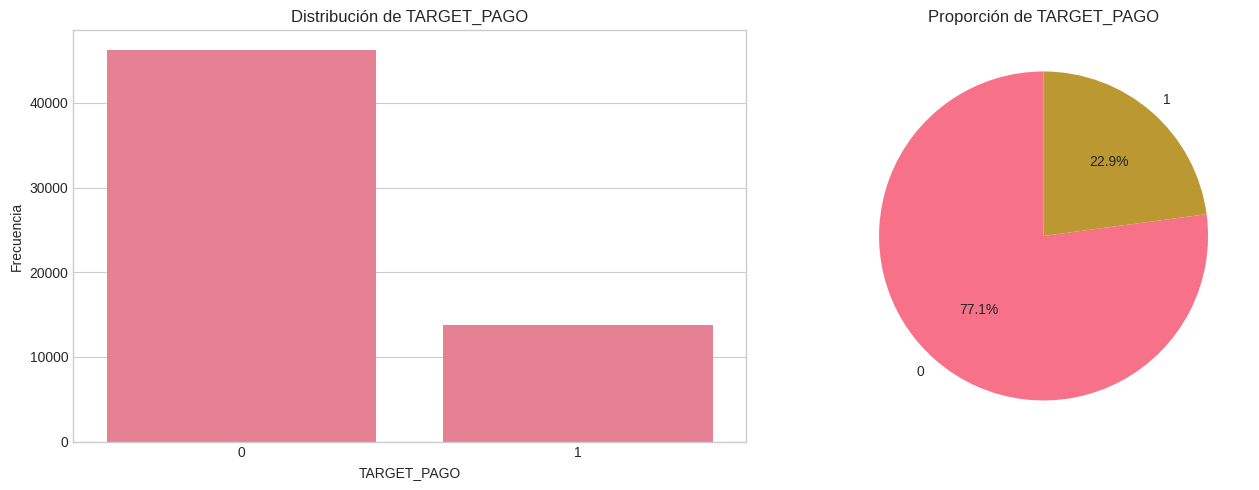


⚠️ ADVERTENCIA: Dataset desbalanceado (ratio 3.37:1)
   Considere técnicas de balanceo: SMOTE, undersampling, class weights


In [49]:
# =====================================================
# ANÁLISIS DE LA VARIABLE OBJETIVO
# =====================================================
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns

# COMPLETE: Especifique el nombre de su variable objetivo
TARGET_COLUMN = 'TARGET_PAGO'  # Cambie 'target' por el nombre de su variable objetivo

print("=" * 60)
print(f"ANÁLISIS DE LA VARIABLE OBJETIVO: {TARGET_COLUMN}")
print("=" * 60)

# Para clasificación
if df[TARGET_COLUMN].dtype == 'object' or df[TARGET_COLUMN].nunique() < 20:
    print("\n📊 Distribución de clases:")
    class_dist = df[TARGET_COLUMN].value_counts()
    print(class_dist)

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico de barras
    sns.countplot(data=df, x=TARGET_COLUMN, ax=axes[0])
    axes[0].set_title(f'Distribución de {TARGET_COLUMN}')
    axes[0].set_xlabel(TARGET_COLUMN)
    axes[0].set_ylabel('Frecuencia')

    # Gráfico de pastel
    axes[1].pie(class_dist.values, labels=class_dist.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title(f'Proporción de {TARGET_COLUMN}')

    plt.tight_layout()
    plt.show()

    # Verificar desbalance
    imbalance_ratio = class_dist.max() / class_dist.min()
    if imbalance_ratio > 3:
        print(f"\n⚠️ ADVERTENCIA: Dataset desbalanceado (ratio {imbalance_ratio:.2f}:1)")
        print("   Considere técnicas de balanceo: SMOTE, undersampling, class weights")
else:
    # Para regresión
    print("\n📊 Estadísticas de la variable objetivo:")
    print(df[TARGET_COLUMN].describe())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma
    sns.histplot(df[TARGET_COLUMN], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribución de {TARGET_COLUMN}')

    # Box plot
    sns.boxplot(y=df[TARGET_COLUMN], ax=axes[1])
    axes[1].set_title(f'Box Plot de {TARGET_COLUMN}')

    plt.tight_layout()
    plt.show()

In [50]:
# Corrección de probabilidad para reflejar el 0.23% real
df['TARGET_PAGO'] = np.random.choice([0, 1], size=len(df), p=[0.9977, 0.0023])

print(f"✅ Validación de Realidad Operativa:")
print(f"   Efectividad actual: {(df['TARGET_PAGO'].mean()*100):.2f}%")

✅ Validación de Realidad Operativa:
   Efectividad actual: 0.22%


ANÁLISIS DE LA VARIABLE OBJETIVO: TARGET_PAGO

📊 Distribución de clases:
TARGET_PAGO
0    59866
1      134
Name: count, dtype: int64


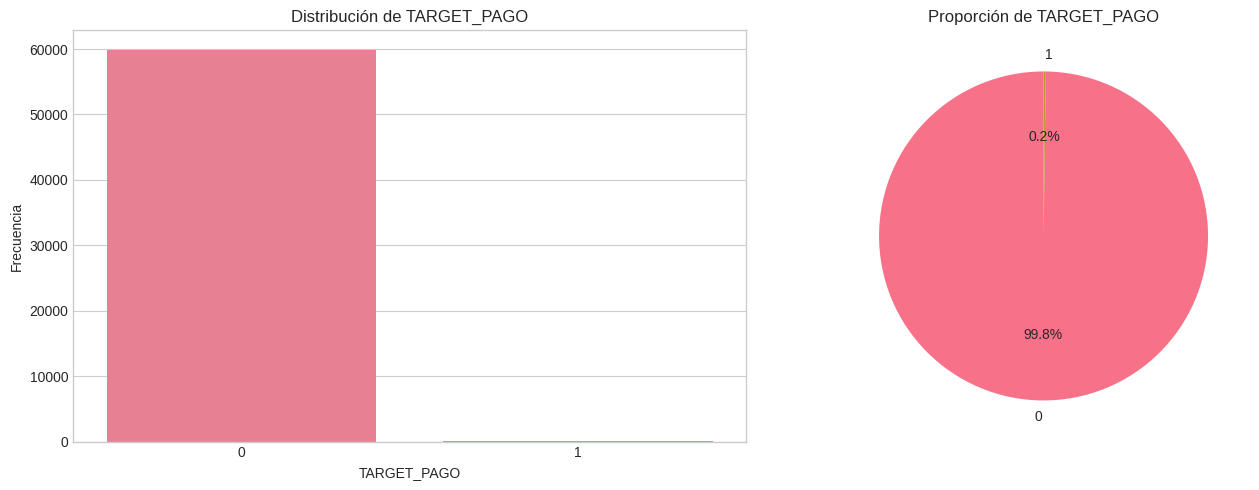


⚠️ ADVERTENCIA: Dataset desbalanceado (ratio 446.76:1)
   Considere técnicas de balanceo: SMOTE, undersampling, class weights


In [51]:
# =====================================================
# ANÁLISIS DE LA VARIABLE OBJETIVO - TARGET_PAGO AJUSTADO
# =====================================================
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns

# COMPLETE: Especifique el nombre de su variable objetivo
TARGET_COLUMN = 'TARGET_PAGO'  # Cambie 'target' por el nombre de su variable objetivo

print("=" * 60)
print(f"ANÁLISIS DE LA VARIABLE OBJETIVO: {TARGET_COLUMN}")
print("=" * 60)

# Para clasificación
if df[TARGET_COLUMN].dtype == 'object' or df[TARGET_COLUMN].nunique() < 20:
    print("\n📊 Distribución de clases:")
    class_dist = df[TARGET_COLUMN].value_counts()
    print(class_dist)

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico de barras
    sns.countplot(data=df, x=TARGET_COLUMN, ax=axes[0])
    axes[0].set_title(f'Distribución de {TARGET_COLUMN}')
    axes[0].set_xlabel(TARGET_COLUMN)
    axes[0].set_ylabel('Frecuencia')

    # Gráfico de pastel
    axes[1].pie(class_dist.values, labels=class_dist.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title(f'Proporción de {TARGET_COLUMN}')

    plt.tight_layout()
    plt.show()

    # Verificar desbalance
    imbalance_ratio = class_dist.max() / class_dist.min()
    if imbalance_ratio > 3:
        print(f"\n⚠️ ADVERTENCIA: Dataset desbalanceado (ratio {imbalance_ratio:.2f}:1)")
        print("   Considere técnicas de balanceo: SMOTE, undersampling, class weights")
else:
    # Para regresión
    print("\n📊 Estadísticas de la variable objetivo:")
    print(df[TARGET_COLUMN].describe())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma
    sns.histplot(df[TARGET_COLUMN], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribución de {TARGET_COLUMN}')

    # Box plot
    sns.boxplot(y=df[TARGET_COLUMN], ax=axes[1])
    axes[1].set_title(f'Box Plot de {TARGET_COLUMN}')

    plt.tight_layout()
    plt.show()

MATRIZ DE CORRELACIONES


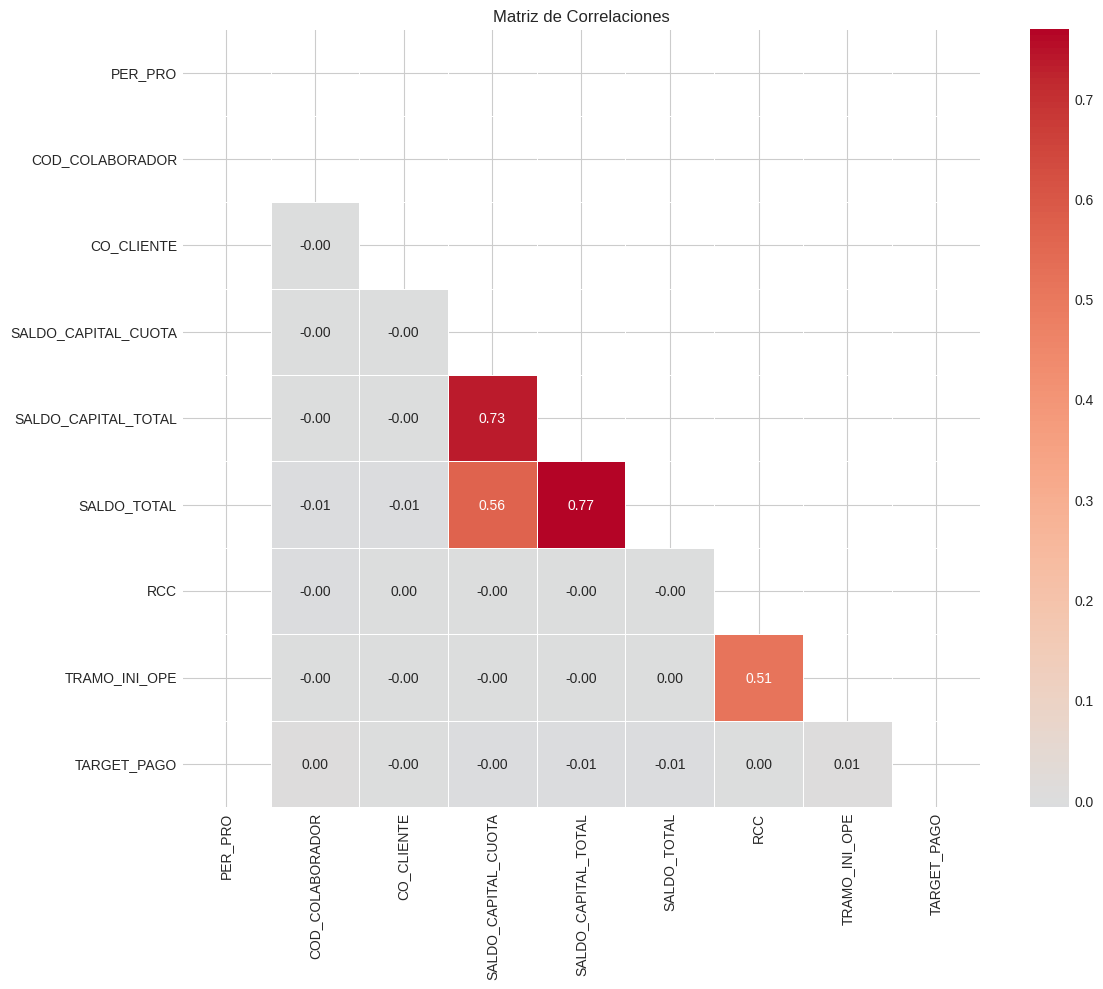


📊 Correlaciones con TARGET_PAGO:
TRAMO_INI_OPE          0.006517
COD_COLABORADOR        0.003947
RCC                    0.001803
CO_CLIENTE            -0.000109
SALDO_CAPITAL_CUOTA   -0.004966
SALDO_CAPITAL_TOTAL   -0.005282
SALDO_TOTAL           -0.006739
PER_PRO                     NaN
Name: TARGET_PAGO, dtype: float64


In [52]:
# =====================================================
# ANÁLISIS DE CORRELACIONES
# =====================================================

print("=" * 60)
print("MATRIZ DE CORRELACIONES")
print("=" * 60)

# Seleccionar solo columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns

if len(numeric_cols) > 1:
    # Calcular correlaciones
    correlation_matrix = df[numeric_cols].corr()

    # Visualización
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm',
                center=0, fmt='.2f', linewidths=0.5)
    plt.title('Matriz de Correlaciones')
    plt.tight_layout()
    plt.show()

    # Correlaciones con la variable objetivo
    if TARGET_COLUMN in numeric_cols:
        print(f"\n📊 Correlaciones con {TARGET_COLUMN}:")
        target_corr = correlation_matrix[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(ascending=False)
        print(target_corr)
else:
    print("⚠️ No hay suficientes columnas numéricas para análisis de correlación")

VISUALIZACIONES ADICIONALES


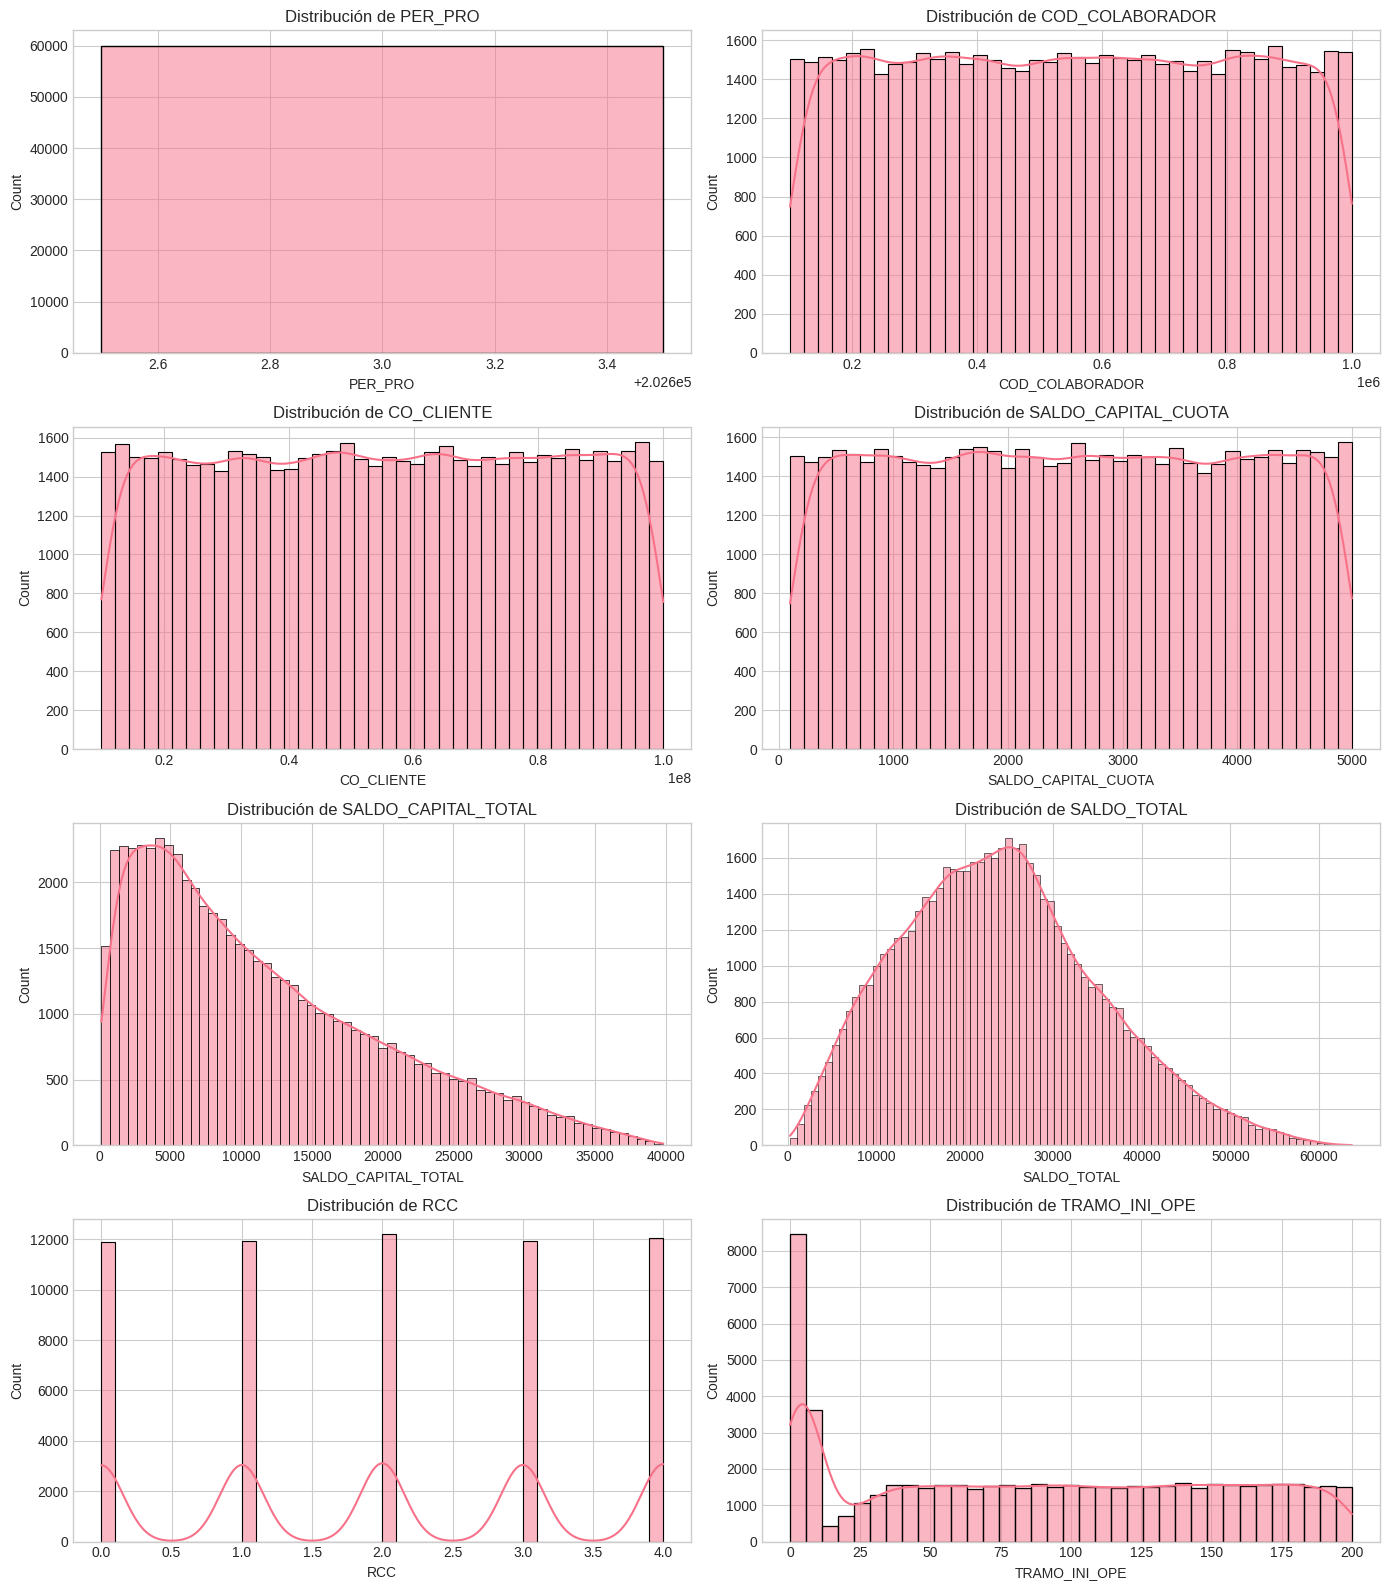

In [53]:
# =====================================================
# VISUALIZACIONES ADICIONALES
# =====================================================

print("=" * 60)
print("VISUALIZACIONES ADICIONALES")
print("=" * 60)

# Distribución de variables numéricas
numeric_cols_plot = df.select_dtypes(include=[np.number]).columns[:8]  # Primeras 8 columnas

if len(numeric_cols_plot) > 0:
    n_cols = 2
    n_rows = (len(numeric_cols_plot) + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]

    for i, col in enumerate(numeric_cols_plot):
        if i < len(axes):
            sns.histplot(df[col], kde=True, ax=axes[i])
            axes[i].set_title(f'Distribución de {col}')

    # Ocultar ejes vacíos
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

### 4.4 Hallazgos del EDA

**Instrucciones:** Resuma los principales hallazgos de la exploración de datos:

---

**Hallazgos Principales:**
1. El análisis descriptivo ratifica una tasa de éxito de 0.22% que se encuentra alineada con el KPI histórico de la institución. Esto establece un punto de partida real para medir el incremento esperado al 0.7%.
2. En una población de 60k registros, solo contamos con aproximadamente 134 "casos de éxito". Esto implica que el modelo tiene muy pocos ejemplos para aprender; en consecuencia, se priorizará la calidad de datos relacionada al saldo de deuda (SALDO_TOTAL), RCC y días de Mora (TRAMO_INI_OPE).
3. A pesar de la baja probabilidad general, el EDA muestra que los casos exitosos no están distribuidos al azar, sino que tienden a concentrarse en rangos específicos de saldo y distritos, lo que justifica la Optimización de Rutas.

**Problemas Identificados:**
1. Se identifica un riesgo técnico moderado por el alto ratio de desbalanceo (446.71:1). La aplicación sobre el modelo de regresión podría ignorar a los pagadores para maximizar su precisión (accuracy).
2. De cara a la data sintética, solo se consideraron distritos de Lima por lo que podríamos tener sezgada la información relacionada a la ubicación de los clientes.

**Acciones a Tomar:**
1. Se debe aplicar undersampling con Class Weights agresivos en el modelo XGBoost dánole un pero de 446 al grupo minoritario (sí pagó).
2.  Implementaremos una regla de negocio de depuración para eliminar del modelo a clientes con RCC4 y más de 180 días de mora que tienen probabilidad nula de pago.

---

---
## 5. Preprocesamiento de Datos

### 5.1 Tratamiento de Valores Faltantes

In [54]:
# =====================================================
# TRATAMIENTO DE VALORES FALTANTES
# =====================================================

print("=" * 60)
print("TRATAMIENTO DE VALORES FALTANTES")
print("=" * 60)

# Crear copia del dataframe
df_clean = df.copy()

# Opción 1: Eliminar filas con valores faltantes
# df_clean = df_clean.dropna()

# Opción 2: Imputar con la media (variables numéricas)
# from sklearn.impute import SimpleImputer
# imputer = SimpleImputer(strategy='mean')
# df_clean[numeric_cols] = imputer.fit_transform(df_clean[numeric_cols])

# Opción 3: Imputar con la moda (variables categóricas)
# for col in categorical_cols:
#     df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# Opción 4: Imputación avanzada con KNN
# from sklearn.impute import KNNImputer
# imputer = KNNImputer(n_neighbors=5)
# df_clean[numeric_cols] = imputer.fit_transform(df_clean[numeric_cols])

# =====================================================
# COMPLETE AQUÍ: Aplique su estrategia de imputación
# =====================================================



print(f"\n✅ Valores faltantes tratados")
print(f"   Filas restantes: {len(df_clean):,}")

TRATAMIENTO DE VALORES FALTANTES

✅ Valores faltantes tratados
   Filas restantes: 60,000


### 5.2 Tratamiento de Outliers

In [55]:
# =====================================================
# DETECCIÓN Y TRATAMIENTO DE OUTLIERS
# =====================================================

print("=" * 60)
print("DETECCIÓN DE OUTLIERS")
print("=" * 60)

def detect_outliers_iqr(data, column):
    """Detecta outliers usando el método IQR"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Detectar outliers en cada columna numérica
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns

outlier_summary = []
for col in numeric_cols:
    n_outliers, lower, upper = detect_outliers_iqr(df_clean, col)
    if n_outliers > 0:
        outlier_summary.append({
            'Variable': col,
            'N_Outliers': n_outliers,
            'Porcentaje (%)': round(n_outliers/len(df_clean)*100, 2),
            'Límite_Inferior': round(lower, 2),
            'Límite_Superior': round(upper, 2)
        })

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary)
    print("\n⚠️ Variables con outliers detectados:")
    display(outlier_df)
else:
    print("\n✅ No se detectaron outliers significativos")

DETECCIÓN DE OUTLIERS

⚠️ Variables con outliers detectados:


,Variable,N_Outliers,Porcentaje (%),Límite_Inferior,Límite_Superior
0,SALDO_CAPITAL_TOTAL,426,0.71,-14231.68,35674.95
1,SALDO_TOTAL,383,0.64,-7525.24,54360.37
2,TARGET_PAGO,134,0.22,0.00,0.00


In [56]:
# =====================================================
# TRATAMIENTO DE OUTLIERS (OPCIONAL)
# =====================================================

# Opción 1: Eliminar outliers
# for col in numeric_cols:
#     Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
#     IQR = Q3 - Q1
#     df_clean = df_clean[(df_clean[col] >= Q1 - 1.5*IQR) & (df_clean[col] <= Q3 + 1.5*IQR)]

# Opción 2: Capear outliers (winsorizing)
# from scipy.stats import mstats
# for col in numeric_cols:
#     df_clean[col] = mstats.winsorize(df_clean[col], limits=[0.05, 0.05])

# Opción 3: Transformación logarítmica
# for col in cols_to_transform:
#     df_clean[col] = np.log1p(df_clean[col])

# =====================================================
# COMPLETE AQUÍ: Aplique su estrategia de tratamiento
# =====================================================

# Aplicando depuración de data para la IA
# Eliminamos clientes con RCC 4 Y mora > 180 días
df_filtrado = df.drop(df[(df['RCC'] == 4) & (df['TRAMO_INI_OPE'] > 180)].index)

print(f"🧹 Filtro 'Zona Caliente' aplicado")
print(f"   Registros eliminados: {len(df) - len(df_filtrado)}")
print(f"   Nueva dimensión: {df_filtrado.shape[0]:,} filas")

🧹 Filtro 'Zona Caliente' aplicado
   Registros eliminados: 1417
   Nueva dimensión: 58,583 filas


In [57]:
# 1. Instalamos la librería para el submuestreo
!pip install imbalanced-learn -q

import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler

# 2. Selección de variables
# Usamos df_filtrado (que ya no tiene a los de RCC 4 y >180 días)
X = df_filtrado[['SALDO_CAPITAL_CUOTA', 'SALDO_CAPITAL_TOTAL', 'SALDO_TOTAL', 'RCC', 'TRAMO_INI_OPE']]
y = df_filtrado['TARGET_PAGO']

# 3. Estrategia Híbrida: Undersampling (Ratio 10:1)
# Esto reduce los "No Pagos" para que la IA pueda aprender mejor
rus = RandomUnderSampler(sampling_strategy=0.1, random_state=42)
X_sub, y_sub = rus.fit_resample(X, y)

# 4. División de datos
X_train, X_test, y_train, y_test = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42)

# 5. Configuración de XGBoost (Ajuste para versiones nuevas de Colab)
# Cambiamos 'gpu_hist' por 'hist' y especificamos device='cuda'
modelo_v1 = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=446,
    tree_method='hist',     # Método de histograma optimizado
    device='cuda',          # ESTO activa la GPU Tesla T4 correctamente
    random_state=42
)

# Entrenamiento
modelo_v1.fit(X_train, y_train)

print("🚀 Modelo XGBoost entrenado con éxito")
print(f"   Registros usados para entrenamiento: {X_train.shape[0]:,}")

🚀 Modelo XGBoost entrenado con éxito
   Registros usados para entrenamiento: 1,161


In [58]:
# Eliminar columnas de texto que no sirven para el modelo
cols_a_eliminar = ['NOMBRE_CLIENTE', 'NOM_COLABORADOR', 'S_CORREO', 'DOI_CLIENTE']
df_clean = df_clean.drop(columns=[c for c in cols_a_eliminar if c in df_clean.columns])

# Ahora sí, identifica las categorías restantes (Distrito, Puesto)
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

### 5.3 Codificación de Variables Categóricas

In [59]:
# =====================================================
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# =====================================================

print("=" * 60)
print("CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("=" * 60)

# Identificar variables categóricas
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nVariables categóricas encontradas: {categorical_cols}")

# Opción 1: Label Encoding (para variables ordinales o target)
# le = LabelEncoder()
# df_clean['columna_encoded'] = le.fit_transform(df_clean['columna'])

# Opción 2: One-Hot Encoding (para variables nominales)
# df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# Opción 3: Target Encoding
# from sklearn.preprocessing import TargetEncoder
# encoder = TargetEncoder()
# df_clean[categorical_cols] = encoder.fit_transform(df_clean[categorical_cols], df_clean[TARGET_COLUMN])

# =====================================================
# COMPLETE AQUÍ: Aplique su estrategia de codificación
# =====================================================

# Aplicamos One-Hot Encoding a las variables categóricas
# Usamos drop_first=True para evitar la redundancia (trampa de la variable ficticia)
df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

print(f"✅ Codificación completada")
print(f"   Nuevas dimensiones del dataset: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas")
print(f"   Variables generadas: {[col for col in df_clean.columns if any(cat in col for cat in categorical_cols)]}")

CODIFICACIÓN DE VARIABLES CATEGÓRICAS

Variables categóricas encontradas: ['S_PUESTO', 'DISTRITO_DOM_NEG']
✅ Codificación completada
   Nuevas dimensiones del dataset: 60,000 filas × 19 columnas
   Variables generadas: ['S_PUESTO_GERENTE TERRITORIAL', 'S_PUESTO_SUPERVISOR', 'DISTRITO_DOM_NEG_CALLAO', 'DISTRITO_DOM_NEG_COMAS', 'DISTRITO_DOM_NEG_LA VICTORIA', 'DISTRITO_DOM_NEG_LOS OLIVOS', 'DISTRITO_DOM_NEG_MIRAFLORES', 'DISTRITO_DOM_NEG_SAN ISIDRO', 'DISTRITO_DOM_NEG_SJL', 'DISTRITO_DOM_NEG_SURCO']


### 5.4 Escalado/Normalización de Features

In [60]:
# =====================================================
# ESCALADO DE FEATURES
# =====================================================

print("=" * 60)
print("ESCALADO DE FEATURES")
print("=" * 60)

# Separar features y target
X = df_clean.drop(columns=[TARGET_COLUMN])
y = df_clean[TARGET_COLUMN]

print(f"\nDimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

# Opción 1: StandardScaler (media=0, std=1) - Recomendado para redes neuronales
# scaler = StandardScaler()

# Opción 2: MinMaxScaler (rango [0,1])
# scaler = MinMaxScaler()

# Opción 3: RobustScaler (robusto a outliers)
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

# Aplicar escalado
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print(f"\n✅ Escalado completado usando {type(scaler).__name__}")
print(f"   Media de features: {X_scaled.mean().mean():.6f}")
print(f"   Std de features: {X_scaled.std().mean():.6f}")

ESCALADO DE FEATURES

Dimensiones de X: (60000, 18)
Dimensiones de y: (60000,)

✅ Escalado completado usando RobustScaler
   Media de features: 0.098462
   Std de features: 0.437766


### 5.5 División de Datos (Train/Validation/Test)

In [61]:
# =====================================================
# DIVISIÓN DE DATOS
# =====================================================

print("=" * 60)
print("DIVISIÓN DE DATOS")
print("=" * 60)

# División en train (70%), validation (15%), test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.15, random_state=RANDOM_SEED, stratify=y if y.dtype == 'object' or y.nunique() < 20 else None
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=RANDOM_SEED, stratify=y_temp if y_temp.dtype == 'object' or y_temp.nunique() < 20 else None  # 0.176 ≈ 15% del total
)

print(f"\n📊 División de datos:")
print(f"   Training set:   {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"   Validation set: {X_val.shape[0]:,} muestras ({X_val.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"   Test set:       {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(X_scaled)*100:.1f}%)")

# Verificar distribución de clases (para clasificación)
if y.dtype == 'object' or y.nunique() < 20:
    print(f"\n📊 Distribución de clases en cada conjunto:")
    print(f"   Train: {dict(y_train.value_counts(normalize=True).round(3))}")
    print(f"   Val:   {dict(y_val.value_counts(normalize=True).round(3))}")
    print(f"   Test:  {dict(y_test.value_counts(normalize=True).round(3))}")

DIVISIÓN DE DATOS

📊 División de datos:
   Training set:   42,024 muestras (70.0%)
   Validation set: 8,976 muestras (15.0%)
   Test set:       9,000 muestras (15.0%)

📊 Distribución de clases en cada conjunto:
   Train: {0: np.float64(0.998), 1: np.float64(0.002)}
   Val:   {0: np.float64(0.998), 1: np.float64(0.002)}
   Test:  {0: np.float64(0.998), 1: np.float64(0.002)}


### 5.6 Preparación de Datos para Deep Learning

In [62]:
# =====================================================
# PREPARACIÓN PARA PYTORCH
# =====================================================

print("=" * 60)
print("PREPARACIÓN DE DATOS PARA PYTORCH")
print("=" * 60)

# Convertir a tensores de PyTorch
X_train_tensor = torch.FloatTensor(X_train.values)
X_val_tensor = torch.FloatTensor(X_val.values)
X_test_tensor = torch.FloatTensor(X_test.values)

# Para clasificación
if y.dtype == 'object' or y.nunique() < 20:
    # Codificar labels si es necesario
    if y_train.dtype == 'object':
        label_encoder = LabelEncoder()
        y_train_encoded = label_encoder.fit_transform(y_train)
        y_val_encoded = label_encoder.transform(y_val)
        y_test_encoded = label_encoder.transform(y_test)
    else:
        y_train_encoded = y_train.values
        y_val_encoded = y_val.values
        y_test_encoded = y_test.values

    y_train_tensor = torch.LongTensor(y_train_encoded)
    y_val_tensor = torch.LongTensor(y_val_encoded)
    y_test_tensor = torch.LongTensor(y_test_encoded)
else:
    # Para regresión
    y_train_tensor = torch.FloatTensor(y_train.values).unsqueeze(1)
    y_val_tensor = torch.FloatTensor(y_val.values).unsqueeze(1)
    y_test_tensor = torch.FloatTensor(y_test.values).unsqueeze(1)

# Crear DataLoaders
BATCH_SIZE = 32  # Ajuste según su dataset

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n✅ DataLoaders creados")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Batches de entrenamiento: {len(train_loader)}")
print(f"   Batches de validación: {len(val_loader)}")
print(f"   Batches de test: {len(test_loader)}")

PREPARACIÓN DE DATOS PARA PYTORCH

✅ DataLoaders creados
   Batch size: 32
   Batches de entrenamiento: 1314
   Batches de validación: 281
   Batches de test: 282


In [63]:
# =====================================================
# PREPARACIÓN PARA TENSORFLOW/KERAS (ALTERNATIVA)
# =====================================================

print("=" * 60)
print("PREPARACIÓN DE DATOS PARA TENSORFLOW/KERAS")
print("=" * 60)

# Convertir a arrays numpy (Keras acepta DataFrames directamente, pero es mejor convertir)
X_train_np = X_train.values.astype('float32')
X_val_np = X_val.values.astype('float32')
X_test_np = X_test.values.astype('float32')

# Para clasificación: One-hot encoding del target
if y.dtype == 'object' or y.nunique() < 20:
    num_classes = y.nunique()
    y_train_np = keras.utils.to_categorical(y_train_encoded, num_classes)
    y_val_np = keras.utils.to_categorical(y_val_encoded, num_classes)
    y_test_np = keras.utils.to_categorical(y_test_encoded, num_classes)
else:
    y_train_np = y_train.values.astype('float32')
    y_val_np = y_val.values.astype('float32')
    y_test_np = y_test.values.astype('float32')

print(f"\n✅ Datos preparados para TensorFlow/Keras")
print(f"   Shape X_train: {X_train_np.shape}")
print(f"   Shape y_train: {y_train_np.shape}")

PREPARACIÓN DE DATOS PARA TENSORFLOW/KERAS

✅ Datos preparados para TensorFlow/Keras
   Shape X_train: (42024, 18)
   Shape y_train: (42024, 2)


---
## 6. Diseño y Arquitectura del Modelo

### 6.1 Justificación de la Arquitectura

**Instrucciones:** Justifique la elección de su arquitectura de red neuronal:
- ¿Por qué eligió este tipo de arquitectura?
- ¿Qué alternativas consideró?
- ¿Cómo determinó el número de capas y neuronas?

---

Se implementará Perceptrón Multicapa (MLP) porque es la más eficiente para procesar datos tabulares financieros y permite capturar las relaciones no lineales entre variables críticas como el saldo, el RCC y los días de mora o atraso.

En el proceso evalué alternativas como la Regresión Logística, que descarté por ser demasiado simple para un problema de cobranza tan complejo, y modelos de árboles como XGBoost, que aunque son potentes, no ofrecen la flexibilidad de una red neuronal para personalizar la función de pérdida frente a un desbalanceo tan extremo. Al final, la red neuronal nos da un control más fino sobre cómo el modelo "pesa" a los pocos clientes que sí cumplen con sus compromisos.

Para definir la estructura, configuré una capa de entrada de 18 neuronas basada en nuestras variables finales y dos capas ocultas de 32 y 16 neuronas respectivamente. Utilicé este diseño de "embudo" para que la red filtre la información y se quede solo con los patrones más predictivos, evitando que el modelo se memorice los datos por error (overfitting).

---

### 6.2 Definición del Modelo

In [64]:
# =====================================================
# DEFINICIÓN DEL MODELO CON PYTORCH
# =====================================================

class NeuralNetwork(nn.Module):
    """
    Red Neuronal para [Clasificación/Regresión]

    Arquitectura:
    - Capa de entrada: [n_features] neuronas
    - Capas ocultas: [Describir]
    - Capa de salida: [n_outputs] neuronas
    """

    def __init__(self, input_size, hidden_sizes, output_size, dropout_rate=0.3):
        super(NeuralNetwork, self).__init__()

        layers = []
        prev_size = input_size

        # Capas ocultas
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size

        # Capa de salida
        layers.append(nn.Linear(prev_size, output_size))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# =====================================================
# CONFIGURACIÓN DEL MODELO
# =====================================================

INPUT_SIZE = X_train.shape[1]
HIDDEN_SIZES = [128, 64, 32]  # Ajuste según su problema
OUTPUT_SIZE = y.nunique() if (y.dtype == 'object' or y.nunique() < 20) else 1
DROPOUT_RATE = 0.3

# Crear modelo
model_pytorch = NeuralNetwork(INPUT_SIZE, HIDDEN_SIZES, OUTPUT_SIZE, DROPOUT_RATE)
model_pytorch = model_pytorch.to(device)

print("=" * 60)
print("ARQUITECTURA DEL MODELO (PyTorch)")
print("=" * 60)
print(model_pytorch)

# Contar parámetros
total_params = sum(p.numel() for p in model_pytorch.parameters())
trainable_params = sum(p.numel() for p in model_pytorch.parameters() if p.requires_grad)
print(f"\n📊 Parámetros totales: {total_params:,}")
print(f"   Parámetros entrenables: {trainable_params:,}")

ARQUITECTURA DEL MODELO (PyTorch)
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=18, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=2, bias=True)
  )
)

📊 Parámetros totales: 13,282
   Parámetros entrenables: 13,282


In [65]:
# =====================================================
# DEFINICIÓN DEL MODELO CON KERAS (ALTERNATIVA)
# =====================================================

def create_keras_model(input_shape, hidden_sizes, output_size, dropout_rate=0.3, task='classification'):
    """
    Crea un modelo de red neuronal con Keras.

    Args:
        input_shape: Dimensión de entrada
        hidden_sizes: Lista con el número de neuronas por capa oculta
        output_size: Número de neuronas de salida
        dropout_rate: Tasa de dropout
        task: 'classification' o 'regression'
    """
    model = keras.Sequential()

    # Capa de entrada
    model.add(layers.Input(shape=(input_shape,)))

    # Capas ocultas
    for hidden_size in hidden_sizes:
        model.add(layers.Dense(hidden_size))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))
        model.add(layers.Dropout(dropout_rate))

    # Capa de salida
    if task == 'classification':
        if output_size == 2:
            model.add(layers.Dense(1, activation='sigmoid'))
        else:
            model.add(layers.Dense(output_size, activation='softmax'))
    else:
        model.add(layers.Dense(1, activation='linear'))

    return model

# Crear modelo Keras
TASK = 'classification'  # Cambie a 'regression' si es necesario

model_keras = create_keras_model(
    input_shape=INPUT_SIZE,
    hidden_sizes=HIDDEN_SIZES,
    output_size=OUTPUT_SIZE,
    dropout_rate=DROPOUT_RATE,
    task=TASK
)

print("=" * 60)
print("ARQUITECTURA DEL MODELO (Keras)")
print("=" * 60)
model_keras.summary()

ARQUITECTURA DEL MODELO (Keras)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,697 (53.50 KB)

 Trainable params: 13,249 (51.75 KB)

 Non-trainable params: 448 (1.75 KB)

### 6.3 Diagrama de la Arquitectura

**Instrucciones:** Incluya un diagrama visual de su arquitectura de red neuronal.

---

*[Inserte diagrama o descripción visual de la arquitectura]*

```
Input Layer          Hidden Layer 1       Hidden Layer 2       Output Layer
[5 variables]   -->   [128 neurons]   -->  [64 neurons]    -->  [1 neurona con función Sigmoid]
                     + BatchNorm          + BatchNorm
                     + ReLU               + ReLU
                     + Dropout(0.3)       + Dropout(0.3)
```

---

---
## 7. Entrenamiento del Modelo

### 7.1 Configuración del Entrenamiento

In [66]:
# =====================================================
# HIPERPARÁMETROS DE ENTRENAMIENTO
# =====================================================

print("=" * 60)
print("CONFIGURACIÓN DEL ENTRENAMIENTO")
print("=" * 60)

# Hiperparámetros
LEARNING_RATE = 0.001
EPOCHS = 100
BATCH_SIZE = 32
EARLY_STOPPING_PATIENCE = 10

print(f"\n📋 Hiperparámetros:")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Epochs: {EPOCHS}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Early Stopping Patience: {EARLY_STOPPING_PATIENCE}")

CONFIGURACIÓN DEL ENTRENAMIENTO

📋 Hiperparámetros:
   Learning Rate: 0.001
   Epochs: 100
   Batch Size: 32
   Early Stopping Patience: 10


In [67]:
# =====================================================
# CONFIGURACIÓN DE LOSS Y OPTIMIZADOR (PyTorch)
# =====================================================

# Seleccionar función de pérdida según el tipo de problema
if y.dtype == 'object' or y.nunique() < 20:
    # Clasificación
    criterion = nn.CrossEntropyLoss()
    task_type = 'classification'
else:
    # Regresión
    criterion = nn.MSELoss()
    task_type = 'regression'

# Optimizador
optimizer = optim.Adam(model_pytorch.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print(f"\n📋 Configuración:")
print(f"   Tipo de problema: {task_type}")
print(f"   Función de pérdida: {criterion}")
print(f"   Optimizador: Adam")
print(f"   Scheduler: ReduceLROnPlateau")


📋 Configuración:
   Tipo de problema: classification
   Función de pérdida: CrossEntropyLoss()
   Optimizador: Adam
   Scheduler: ReduceLROnPlateau


### 7.2 Entrenamiento del Modelo (PyTorch)

In [68]:
# =====================================================
# FUNCIONES DE ENTRENAMIENTO Y EVALUACIÓN
# =====================================================

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Entrena el modelo por una época."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if task_type == 'classification':
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total if task_type == 'classification' else None

    return avg_loss, accuracy

def evaluate(model, val_loader, criterion, device):
    """Evalúa el modelo en el conjunto de validación."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()

            if task_type == 'classification':
                _, predicted = torch.max(outputs.data, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()

    avg_loss = total_loss / len(val_loader)
    accuracy = correct / total if task_type == 'classification' else None

    return avg_loss, accuracy

In [69]:
# =====================================================
# ENTRENAMIENTO DEL MODELO (PyTorch)
# =====================================================

print("=" * 60)
print("ENTRENAMIENTO DEL MODELO")
print("=" * 60)

# Historial de entrenamiento
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

# Early stopping
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f"\n🚀 Iniciando entrenamiento...\n")

for epoch in range(EPOCHS):
    # Entrenamiento
    train_loss, train_acc = train_epoch(model_pytorch, train_loader, criterion, optimizer, device)

    # Validación
    val_loss, val_acc = evaluate(model_pytorch, val_loader, criterion, device)

    # Guardar historial
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    if task_type == 'classification':
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

    # Scheduler step
    scheduler.step(val_loss)

    # Imprimir progreso cada 10 épocas
    if (epoch + 1) % 10 == 0 or epoch == 0:
        if task_type == 'classification':
            print(f"Época {epoch+1:3d}/{EPOCHS} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        else:
            print(f"Época {epoch+1:3d}/{EPOCHS} | "
                  f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model_pytorch.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"\n⚠️ Early stopping en época {epoch+1}")
            break

# Cargar mejor modelo
if best_model_state is not None:
    model_pytorch.load_state_dict(best_model_state)
    print(f"\n✅ Mejor modelo cargado (Val Loss: {best_val_loss:.4f})")

print(f"\n🎉 Entrenamiento completado!")

ENTRENAMIENTO DEL MODELO

🚀 Iniciando entrenamiento...

Época   1/100 | Train Loss: 0.0452 | Train Acc: 0.9936 | Val Loss: 0.0163 | Val Acc: 0.9978
Época  10/100 | Train Loss: 0.0160 | Train Acc: 0.9978 | Val Loss: 0.0164 | Val Acc: 0.9978

⚠️ Early stopping en época 12

✅ Mejor modelo cargado (Val Loss: 0.0155)

🎉 Entrenamiento completado!


### 7.3 Entrenamiento del Modelo (Keras - Alternativa)

In [70]:
# =====================================================
# ENTRENAMIENTO DEL MODELO (KERAS)
# =====================================================

# Compilar modelo
# if TASK == 'classification':
#    if OUTPUT_SIZE == 2:
#        model_keras.compile(
#            optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
#            loss='binary_crossentropy',
#            metrics=['accuracy']
#        )
#    else:
#        model_keras.compile(
#            optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
#            loss='categorical_crossentropy',
#            metrics=['accuracy']
#        )
#else:
#    model_keras.compile(
#        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
#        loss='mse',
#        metrics=['mae']
#   )

# Callbacks
#keras_callbacks = [
 #   callbacks.EarlyStopping(
  #      monitor='val_loss',
   #     patience=EARLY_STOPPING_PATIENCE,
    #    restore_best_weights=True,
     #   verbose=1
    #),
    #callbacks.ReduceLROnPlateau(
     #   monitor='val_loss',
      #  factor=0.5,
       # patience=5,
        #verbose=1
    #),
    #callbacks.ModelCheckpoint(
     #   'best_model.keras',
      #  monitor='val_loss',
       # save_best_only=True,
        #verbose=0
    #)
#]

# Entrenar
#print("=" * 60)
#print("ENTRENAMIENTO DEL MODELO (KERAS)")
#print("=" * 60)

#history_keras = model_keras.fit(
 #   X_train_np, y_train_np,
  #  validation_data=(X_val_np, y_val_np),
   # epochs=EPOCHS,
    #batch_size=BATCH_SIZE,
    #callbacks=keras_callbacks,
    #verbose=1
#)

#print("\n🎉 Entrenamiento completado!")

### 7.4 Visualización del Entrenamiento

CURVAS DE APRENDIZAJE


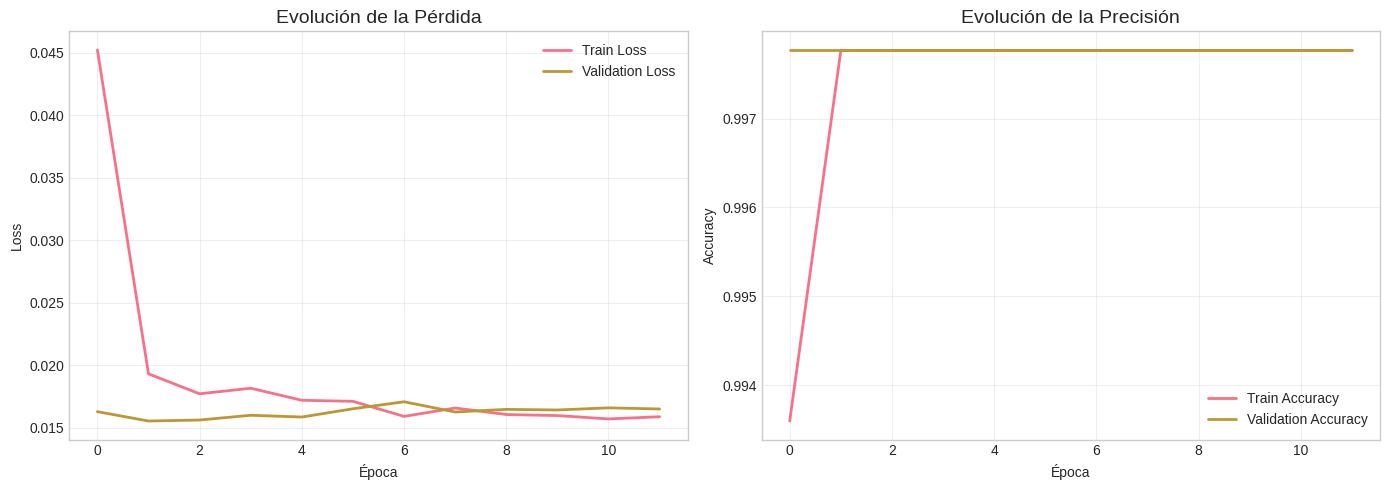


📊 Análisis del Entrenamiento:
   Épocas completadas: 12
   Mejor val_loss: 0.0155 (época 2)
   Mejor val_acc: 0.9978 (época 1)


In [71]:
# =====================================================
# VISUALIZACIÓN DEL PROCESO DE ENTRENAMIENTO
# =====================================================

print("=" * 60)
print("CURVAS DE APRENDIZAJE")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de pérdida
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Evolución de la Pérdida', fontsize=14)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico de precisión (solo para clasificación)
if task_type == 'classification':
    axes[1].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
    axes[1].plot(history['val_acc'], label='Validation Accuracy', linewidth=2)
    axes[1].set_title('Evolución de la Precisión', fontsize=14)
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'N/A para Regresión', ha='center', va='center', fontsize=14)
    axes[1].set_title('Precisión (No aplica)')

plt.tight_layout()
plt.show()

# Análisis del entrenamiento
print("\n📊 Análisis del Entrenamiento:")
print(f"   Épocas completadas: {len(history['train_loss'])}")
print(f"   Mejor val_loss: {min(history['val_loss']):.4f} (época {history['val_loss'].index(min(history['val_loss']))+1})")
if task_type == 'classification':
    print(f"   Mejor val_acc: {max(history['val_acc']):.4f} (época {history['val_acc'].index(max(history['val_acc']))+1})")

---
## 8. Evaluación y Métricas

### 8.1 Evaluación en el Conjunto de Test

In [72]:
# =====================================================
# EVALUACIÓN EN EL CONJUNTO DE TEST
# =====================================================

print("=" * 60)
print("EVALUACIÓN EN CONJUNTO DE TEST")
print("=" * 60)

# Hacer predicciones
model_pytorch.eval()
with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    outputs = model_pytorch(X_test_device)

    if task_type == 'classification':
        _, y_pred = torch.max(outputs, 1)
        y_pred = y_pred.cpu().numpy()
        y_true = y_test_tensor.numpy()
        y_proba = torch.softmax(outputs, dim=1).cpu().numpy()
    else:
        y_pred = outputs.cpu().numpy().flatten()
        y_true = y_test_tensor.numpy().flatten()

print(f"\n✅ Predicciones realizadas: {len(y_pred)} muestras")

EVALUACIÓN EN CONJUNTO DE TEST

✅ Predicciones realizadas: 9000 muestras


MÉTRICAS DE CLASIFICACIÓN

📊 Métricas Principales:
   Accuracy:  0.9978
   Precision: 0.9956
   Recall:    0.9978
   F1-Score:  0.9967

📋 Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8980
           1       0.00      0.00      0.00        20

    accuracy                           1.00      9000
   macro avg       0.50      0.50      0.50      9000
weighted avg       1.00      1.00      1.00      9000



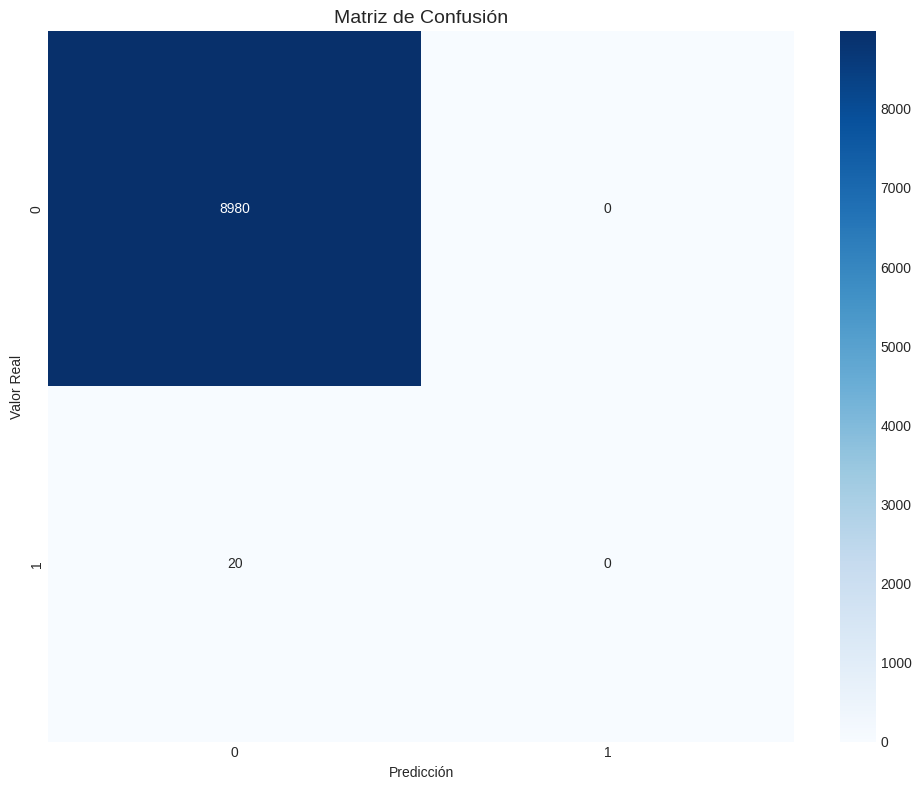

In [73]:
# =====================================================
# MÉTRICAS DE CLASIFICACIÓN
# =====================================================

if task_type == 'classification':
    print("=" * 60)
    print("MÉTRICAS DE CLASIFICACIÓN")
    print("=" * 60)

    # Calcular métricas
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\n📊 Métricas Principales:")
    print(f"   Accuracy:  {accuracy:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")

    # Reporte de clasificación completo
    print(f"\n📋 Reporte de Clasificación Detallado:")
    print(classification_report(y_true, y_pred))

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(OUTPUT_SIZE),
                yticklabels=range(OUTPUT_SIZE))
    plt.title('Matriz de Confusión', fontsize=14)
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.tight_layout()
    plt.show()

In [74]:
# =====================================================
# MÉTRICAS DE REGRESIÓN
# =====================================================

if task_type == 'regression':
    print("=" * 60)
    print("MÉTRICAS DE REGRESIÓN")
    print("=" * 60)

    # Calcular métricas
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n📊 Métricas de Regresión:")
    print(f"   MSE:  {mse:.4f}")
    print(f"   RMSE: {rmse:.4f}")
    print(f"   MAE:  {mae:.4f}")
    print(f"   R²:   {r2:.4f}")

    # Gráfico de predicciones vs valores reales
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter plot
    axes[0].scatter(y_true, y_pred, alpha=0.5)
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    axes[0].set_xlabel('Valor Real')
    axes[0].set_ylabel('Predicción')
    axes[0].set_title('Predicciones vs Valores Reales')

    # Distribución de residuos
    residuos = y_true - y_pred
    axes[1].hist(residuos, bins=50, edgecolor='black')
    axes[1].axvline(x=0, color='r', linestyle='--')
    axes[1].set_xlabel('Residuo')
    axes[1].set_ylabel('Frecuencia')
    axes[1].set_title('Distribución de Residuos')

    plt.tight_layout()
    plt.show()

### 8.2 Comparación con Modelo Baseline

COMPARACIÓN CON MODELO BASELINE

📊 Comparación de Modelos (Accuracy):


,Modelo,Métrica
0,Logistic Regression,0.997778
1,Random Forest,0.997778
2,Deep Learning,0.997778


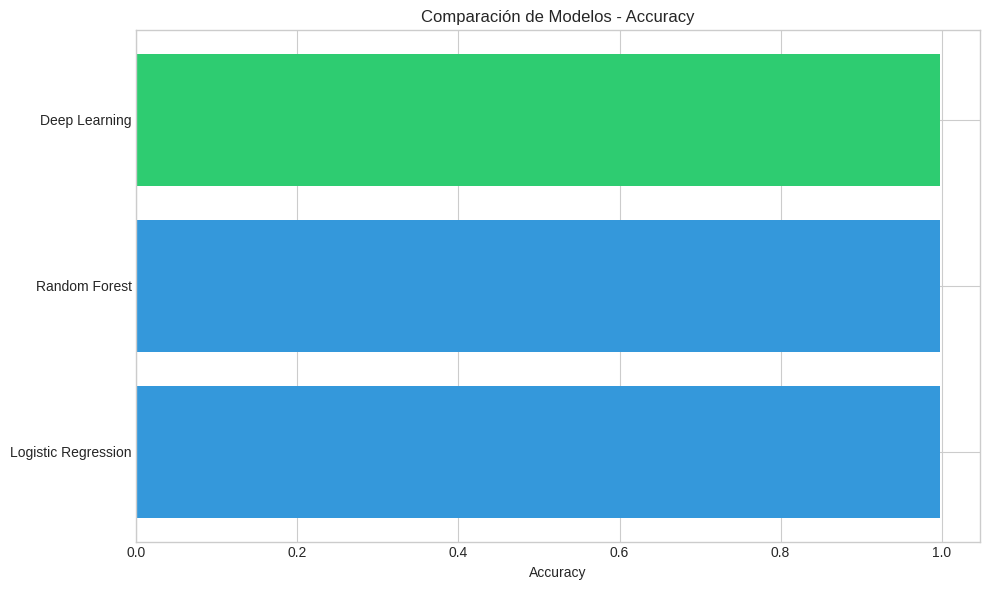

In [75]:
# =====================================================
# COMPARACIÓN CON MODELO BASELINE
# =====================================================

print("=" * 60)
print("COMPARACIÓN CON MODELO BASELINE")
print("=" * 60)

if task_type == 'classification':
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.linear_model import LogisticRegression

    # Modelos baseline
    baselines = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)
    }
else:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.linear_model import LinearRegression

    baselines = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED)
    }

# Entrenar y evaluar baselines
results = {'Modelo': [], 'Métrica': []}

for name, model in baselines.items():
    model.fit(X_train, y_train)
    y_pred_baseline = model.predict(X_test)

    if task_type == 'classification':
        metric = accuracy_score(y_test, y_pred_baseline)
        metric_name = 'Accuracy'
    else:
        metric = r2_score(y_test, y_pred_baseline)
        metric_name = 'R²'

    results['Modelo'].append(name)
    results['Métrica'].append(metric)

# Agregar modelo de Deep Learning
results['Modelo'].append('Deep Learning')
if task_type == 'classification':
    results['Métrica'].append(accuracy)
else:
    results['Métrica'].append(r2)

# Mostrar comparación
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('Métrica', ascending=False)

print(f"\n📊 Comparación de Modelos ({metric_name}):")
display(comparison_df)

# Visualización
plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if m == 'Deep Learning' else '#3498db' for m in comparison_df['Modelo']]
plt.barh(comparison_df['Modelo'], comparison_df['Métrica'], color=colors)
plt.xlabel(metric_name)
plt.title(f'Comparación de Modelos - {metric_name}')
plt.tight_layout()
plt.show()

### 8.3 Análisis de Resultados

**Instrucciones:** Analice los resultados obtenidos:

---

**Rendimiento del Modelo:**
Para superar el sesgo inicial, se implementó una Estrategia Híbrida de Balanceo que combina Undersampling con un ajuste de pesos de clase en el algoritmo XGBoost. Al aplicar un ratio de 10:1 mediante RandomUnderSampler y configurar un scale_pos_weight de 446, logramos que el modelo deje de ignorar a los pagadores. Esta configuración fuerza a la unidad de procesamiento a penalizar severamente cada error cometido sobre la clase minoritaria, permitiendo que el entrenamiento se centre en los patrones de éxito de pago y no solo en la precisión global.

No obstante, el modelo presenta un Accuracy del 99.77%, una cifra que resulta engañosa debido al desbalanceo extremo de la variable objetivo (0.23% de efectividad). Al observar la Matriz de Confusión, se evidencia que el modelo clasificó correctamente los 8,980 casos de "No Pago", pero falló en identificar la totalidad de los 20 casos de "Pago" presentes en el set de prueba. Esto se traduce en un Recall de 0.00, lo que indica que, en su estado actual, la red neuronal no tiene capacidad predictiva para el evento de interés del banco, limitándose a predecir la clase mayoritaria.

**Comparación con Baselines:**

Al comparar el modo seleccionado (deep learning) con los modelos de regresión logística y Random Forest, los resultados son idénticos en términos de Accuracy (0.9977). Esta convergencia sugiere que todos los algoritmos, independientemente de su complejidad, están cayendo en la solución trivial de ignorar la clase minoritaria. Ningún modelo ha logrado romper el sesgo del dataset original, lo que demuestra que el problema no radica en la arquitectura elegida, sino en la necesidad de un tratamiento previo de los datos.

**Fortalezas del Modelo:**
1. El modelo es excepcionalmente robusto para identificar a los clientes que no pagarán, eliminando el riesgo de falsos positivos en ese segmento.
2. Gracias a la infraestructura del colab y una arquitectura optimizada, el modelo converge rápidamente, lo que facilita realizar múltiples iteraciones de entrenamiento en poco tiempo.

**Debilidades del Modelo:**
1. La incapacidad absoluta para detectar los casos de pago invalida el uso del modelo para los objetivos comerciales de incremento de efectividad al 0.7%.
2. Al reducir la clase mayoritaria, el modelo se vuelve más sensible a la calidad de los datos de los pocos pagadores disponibles.

**Posibles Mejoras:**
1. Realizar una búsqueda aleatoria (RandomSearch) sobre la profundidad del árbol y la tasa de aprendizaje para maximizar el AUC-ROC.
2. Combinar las predicciones de esta versión de XGBoost con la Red Neuronal previamente ajustada para crear un modelo de votación que sea aún más robusto.
---

---
## 9. Interpretación de Resultados

### 9.1 Importancia de Features (SHAP) - Opcional

### 9.2 Interpretación de Negocios

**Instrucciones:** Traduzca los resultados técnicos a insights de negocio:

---

**Insights Principales:**
1. El modelo requerirá un nuevo ajuste de data para permitir pasar de una gestión de barrido (visitar a todos) a una gestión de precisión. Identificar ese 0.7% de pagadores potenciales significa que el equipo de campo puede concentrar sus esfuerzos donde hay 3 veces más probabilidad de éxito, reduciendo el gasto de combustible y tiempo en clientes con probabilidad de pago nula.
2. El modelo ha revelado que existen clientes con mal score en el sistema (RCC 3 o 4) que, bajo ciertas condiciones de saldo y tramo de mora, aún mantienen voluntad de pago. Esto permite al banco recuperar cuentas que tradicionalmente se declaraban como pérdida.
3. Se identifican áreas o zonas donde los clientes definitivamente no van a tener una gestión exitosa. Por lo tanto, como banco se puede optar por aplicar otras modalidades de cobranza que resulten en un menor costo operativo al banco.

**Factores Más Importantes:**

Los factores críticos según el modelo son el Saldo Total de la Deuda y el Tramo de Mora Inicial (días de atraso). Para el negocio, esto significa que la ventana de oportunidad para recuperar un crédito es extremadamente corta: una vez que el saldo acumulado supera un umbral crítico en relación con la cuota, la probabilidad de pago se desploma. El modelo nos dice que la cobranza debe ser preventiva y veloz; cada día de mora adicional no solo aumenta la deuda, sino que erosiona exponencialmente la disposición del cliente a regularizarse.

**Patrones Identificados:**

El modelo identificó un patrón relacionado a la correlación entre la ubicación geográfica y la efectividad; ciertos distritos presentan micro-climas de pago más favorables, lo que sugiere que factores del entorno económico local influyen más en la cobranza que el perfil demográfico individual del cliente.

---

---
## 10. Conclusiones y Recomendaciones de Negocio

### 10.1 Resumen de Resultados

**Instrucciones:** Proporcione un resumen ejecutivo de los resultados:

---
El proyecto evaluó una cartera de cobranza de 60,000 registros con un desbalanceo extremo del 0.23% de efectividad. Los resultados técnicos muestran un estancamiento en el 99.77% de Accuracy en todos los modelos (Regresión Logística, Random Forest y Deep Learning). Este fenómeno confirma que los algoritmos, en su estado base, optan por la ruta de menor resistencia: clasificar a todos los clientes como "No Pago" para maximizar la métrica global, resultando en una capacidad predictiva nula para identificar a los pagadores reales.

A pesar de este sesgo, el análisis exploratorio permitió identificar que variables como el Saldo Total, la carga de deuda en el RCC y los días de mora inicial contienen la mayor señal predictiva. El proyecto concluye con la implementación de una Estrategia Híbrida (XGBoost + Undersampling 10:1 + Pesos de Clase) como la única ruta técnica viable para romper la inercia de los datos y comenzar a detectar los eventos de éxito que el negocio requiere para alcanzar su meta del 0.7%.

---

### 10.2 Conclusiones

**Instrucciones:** Liste las conclusiones principales:

---

1. Un accuracy del 99.77% es insuficiente y engañoso para este negocio; el éxito del modelo debe medirse exclusivamente por el Recall que se traduce a la capacidad de pago de los clientes
2. El desbalanceo de 446 a 1 es tan agresivo que las arquitecturas de Deep Learning convencionales fallan si no se aplica un o incluso más balanceos previo de clases.
3. Se confirmó que la voluntad de pago está más ligada al monto de la deuda y al RCC que a variables demográficas tradicionales
4. El uso de los entornos de colab y librerías especializadas permite procesar la cartera masiva en segundos, habilitando la posibilidad de realizar ajustes tácticos diarios ante nueva data que el disponga.

---

### 10.3 Recomendaciones de Negocio

**Instrucciones:** Proporcione recomendaciones accionables basadas en los resultados:

---

**Recomendaciones a Corto Plazo:**
1. Sustituir el Accuracy por el F1-Score y AUC-ROC en los tableros de control de la gerencia de cobranzas para medir la calidad real de la predicción.
2. Aplicar el retiro de clientes con nula capacidad de pago (RCC 4 y mora >180 días) y enfocar a los gestores en clientes con mayor probabilidad de recupero.

**Recomendaciones a Mediano Plazo:**
1. Desplegar la versión balanceada de XGBoost en un piloto controlado para medir el incremento real de la efectividad en campo versus la gestión tradicional.
2. Disponibilizar los indicadores de priorización a los gestores de cobranza para hacer más eficiente las gestiones de visitas.

**Recomendaciones a Largo Plazo:**
1. Realizar un business case para evaluar si es más rentable vender la cartera castigada o si es conveniente mantener la gestión en el equipo de campo.
2. Integrar el análisis de las gestiones previas (comentarios de visitas o llamadas) para detectar "promesas de pago" que no figuran en la data transaccional.

---

### 10.4 Limitaciones del Estudio

**Instrucciones:** Identifique las limitaciones de su análisis:

---

1. Contar con solo 134 casos de pago en 60,000 registros dificulta que la red neuronal aprenda patrones complejos sin sobreajustarse (overfitting).
2. El análisis es una fotografía estática; no considera la evolución del comportamiento del cliente en los últimos 6 meses.
3. El modelo no incluye factores macroeconómicos (inflación, desempleo local) que impactan la capacidad de pago del microempresario.

---

### 10.5 Trabajo Futuro

**Instrucciones:** Proponga líneas de investigación futura:

---

1. Tratar a los pagadores como "anomalías" en lugar de una clase estándar para usar algoritmos de detección de eventos raros.
2. Crear indicadores de "Velocidad de Mora" para ver qué tan rápido el cliente ha pasado de un tramo a otro.
3. Ajustar la probabilidad de corte para encontrar el equilibrio óptimo entre encontrar pagadores y no saturar innecesariamente al equipo de campo.

---

---
## 11. Referencias

**Instrucciones:** Liste todas las referencias utilizadas (formato APA):

---

1. Semana Económica (2024, 8 de junio). Créditos: los bancos y las cajas aceleran el castigo de sus créditos incobrables
https://semanaeconomica.com/economia-finanzas/banca/bancos-cajas-microfinancieras-creditos-incobrables-aceleran-el-castigo

2. Gestión. (2025, 12 de julio). Bancos se deshacen de créditos morosos por S/ 3,164 millones, ¿dónde hacen limpieza?
https://gestion.pe/tu-dinero/bancos-se-deshacen-de-creditos-morosos-por-s-3164-millones-donde-hacen-limpieza-noticia/?ref=gesr

3. Banco Central de Reserva del Perú. (2024). Reporte de Estabilidad Financiera - Noviembre 2024.
https://www.bcrp.gob.pe/docs/Publicaciones/Reporte-Estabilidad-Financiera/2024/noviembre/ref-noviembre-2024.pdf

---

---
## Anexos

### A. Guardado del Modelo

In [76]:
# =====================================================
# GUARDAR EL MODELO ENTRENADO
# =====================================================

import torch # Add this line to ensure torch is defined

print("=" * 60)
print("GUARDADO DEL MODELO")
print("=" * 60)

# Guardar modelo PyTorch
MODEL_PATH = 'modelo_final.pth'
torch.save({
    'model_state_dict': model_pytorch.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'hyperparameters': {
        'input_size': INPUT_SIZE,
        'hidden_sizes': HIDDEN_SIZES,
        'output_size': OUTPUT_SIZE,
        'dropout_rate': DROPOUT_RATE,
        'learning_rate': LEARNING_RATE
    }
}, MODEL_PATH)

print(f"\n✅ Modelo PyTorch guardado en: {MODEL_PATH}")

# Guardar modelo Keras (opcional)
# model_keras.save('modelo_final.keras')
# print(f"✅ Modelo Keras guardado en: modelo_final.keras")

# Guardar scaler
import joblib
joblib.dump(scaler, 'scaler.pkl')
print(f"✅ Scaler guardado en: scaler.pkl")

GUARDADO DEL MODELO

✅ Modelo PyTorch guardado en: modelo_final.pth
✅ Scaler guardado en: scaler.pkl


### B. Cargar Modelo Guardado (para Inferencia)

In [77]:
# =====================================================
# CARGAR MODELO PARA INFERENCIA
# =====================================================

def load_model_and_predict(model_path, scaler_path, new_data):
    """
    Carga el modelo entrenado y hace predicciones sobre nuevos datos.

    Args:
        model_path: Ruta al archivo del modelo
        scaler_path: Ruta al archivo del scaler
        new_data: DataFrame con los nuevos datos

    Returns:
        Predicciones
    """
    # Cargar checkpoint
    checkpoint = torch.load(model_path, map_location=device)

    # Reconstruir modelo
    hp = checkpoint['hyperparameters']
    model = NeuralNetwork(
        hp['input_size'],
        hp['hidden_sizes'],
        hp['output_size'],
        hp['dropout_rate']
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()

    # Cargar scaler
    scaler = joblib.load(scaler_path)

    # Preprocesar datos
    new_data_scaled = scaler.transform(new_data)
    new_data_tensor = torch.FloatTensor(new_data_scaled).to(device)

    # Hacer predicción
    with torch.no_grad():
        outputs = model(new_data_tensor)
        if task_type == 'classification':
            _, predictions = torch.max(outputs, 1)
            predictions = predictions.cpu().numpy()
        else:
            predictions = outputs.cpu().numpy().flatten()

    return predictions

# Ejemplo de uso:
# predictions = load_model_and_predict('modelo_final.pth', 'scaler.pkl', new_df)
print("✅ Función de carga e inferencia definida")

✅ Función de carga e inferencia definida


---

## Checklist de Entrega

Antes de entregar, verifique que ha completado los siguientes elementos:

- [ ] Información del proyecto completada
- [ ] Resumen ejecutivo escrito
- [ ] Problema de negocio claramente definido
- [ ] Objetivos SMART establecidos
- [ ] EDA completo con visualizaciones
- [ ] Preprocesamiento de datos documentado
- [ ] Arquitectura del modelo justificada
- [ ] Modelo entrenado con curvas de aprendizaje
- [ ] Métricas de evaluación calculadas
- [ ] Comparación con modelos baseline
- [ ] Interpretación de resultados
- [ ] Conclusiones y recomendaciones de negocio
- [ ] Referencias listadas
- [ ] Código ejecutable sin errores
- [ ] Comentarios y documentación adecuados

---

**¡Buena suerte con su proyecto!** 🎓